**Nombres**
- Joel Felipe Alba Acosta

**Librerías**
- 

In [83]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import geopandas as gpd
import folium
import os
from scipy.stats import chisquare,ks_2samp
from matplotlib.ticker import FuncFormatter
from folium.plugins import HeatMap
from IPython.display import IFrame, display
from dotenv import load_dotenv

load_dotenv('../.env', override=True)

CARTO_KEY = os.getenv("CARTO_API_KEY")

# **1. Carga y Análisis Básico de Base de Datos**

## **1.1 Carga Base de Datos**

In [84]:
df = pd.read_csv("../data/train.csv")
boroughs = gpd.read_file("../data/Borough_Boundaries_20260910.geojson")
districts = gpd.read_file("../data/Community_Districts_20260910.geojson")

df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


## **1.2 Análisis Básico**

In [85]:
shape = df.shape

print(f"Filas: {shape[0]}, Columnas: {shape[1]}")

Filas: 1458644, Columnas: 11


In [86]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  str    
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  str    
 3   dropoff_datetime    1458644 non-null  str    
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  str    
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), str(4)
memory usage: 122.4 MB


**Observaciones**
- No existen registros nulos

In [87]:
duplicados = df[df.drop(columns=['id']).duplicated(keep=False)]

duplicados = duplicados.sort_values(
    by=df.columns.drop('id').tolist()
)

duplicados

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
1135493,id3603778,2,2016-01-21 12:04:53,2016-01-21 13:35:06,3,-73.800667,40.645954,-73.985809,40.763363,N,5413
1422084,id0978620,2,2016-01-21 12:04:53,2016-01-21 13:35:06,3,-73.800667,40.645954,-73.985809,40.763363,N,5413
212931,id2805144,2,2016-02-16 21:36:35,2016-02-16 21:37:06,2,-74.008034,40.723553,-74.008034,40.723553,N,31
1333727,id0133335,2,2016-02-16 21:36:35,2016-02-16 21:37:06,2,-74.008034,40.723553,-74.008034,40.723553,N,31
403880,id2290238,2,2016-03-05 18:22:41,2016-03-05 18:25:10,2,-73.997292,40.691071,-73.999428,40.683388,N,149
840075,id0946562,2,2016-03-05 18:22:41,2016-03-05 18:25:10,2,-73.997292,40.691071,-73.999428,40.683388,N,149
445735,id1067917,2,2016-03-06 10:06:31,2016-03-07 09:59:05,4,-73.997055,40.737183,-73.991913,40.734577,N,85954
728313,id2386705,2,2016-03-06 10:06:31,2016-03-07 09:59:05,4,-73.997055,40.737183,-73.991913,40.734577,N,85954
1196478,id1417596,2,2016-03-12 16:41:35,2016-03-12 16:47:54,1,-73.974533,40.742298,-73.979507,40.750549,N,379
1407182,id0146524,2,2016-03-12 16:41:35,2016-03-12 16:47:54,1,-73.974533,40.742298,-73.979507,40.750549,N,379


**Observaciones**
- Quitando el id, existen registros duplicados. No obstante, se considera que la existencia de estos duplicados puede ser un evento real (concurrencia de eventos) y no un problema estructural de la data.

In [88]:
for c in df.columns:
    print(f"Valores Únicos {c}: {df[c].nunique()}")

Valores Únicos id: 1458644
Valores Únicos vendor_id: 2
Valores Únicos pickup_datetime: 1380222
Valores Únicos dropoff_datetime: 1380377
Valores Únicos passenger_count: 10
Valores Únicos pickup_longitude: 23047
Valores Únicos pickup_latitude: 45245
Valores Únicos dropoff_longitude: 33821
Valores Únicos dropoff_latitude: 62519
Valores Únicos store_and_fwd_flag: 2
Valores Únicos trip_duration: 7417


**Observaciones**
- El id es único
- Existen solo dos vendedores.
- Store and store_and_fwd_flag es una variable binaria.

## **1.3 Visualizaciones**

In [89]:
def formatear_numero(numero):
    if abs(numero) >= 1_000_000_000:
        return f'{numero / 1_000_000_000:.1f}B'
    elif abs(numero) >= 1_000_000:
        return f'{numero / 1_000_000:.1f}M'
    elif abs(numero) >= 1_000:
        return f'{numero / 1_000:.1f}k'
    else:
        return f'{numero:g}'
def hist_kde(df,columna, percentil=99):

    poblacion = df[columna].dropna()

    # Límite visual para evitar que los extremos oculten la distribución
    limite = np.percentile(
        poblacion,
        percentil
    )

    poblacion_plot = poblacion[poblacion <= limite]
    # Mismos bins para ambas distribuciones
    bins = np.histogram_bin_edges(poblacion_plot, bins='auto')

    # Gráfico
    plt.figure(figsize=(10, 6))

    # Histogramas
    plt.hist(
        poblacion_plot,
        bins=bins,
        density=True,
        alpha=0.35,
        edgecolor='black',
        label='Dataset depurado'
    )

    plt.show()

    # KDE
    sns.kdeplot(
        poblacion_plot,
        linewidth=2,
        label='KDE - Dataset depurado'
    )

    plt.xlabel(columna)
    plt.ylabel('Densidad')
    plt.title(
        f'Distribución de {columna} '
        f'(hasta P{percentil})'
    )

    plt.legend()
    plt.tight_layout()
    plt.show()
def diagrama_barras(df, columna, titulo=None):

    # Crear gráfico
    fig, ax = plt.subplots(figsize=(10, 6))

    # Diagrama de barras
    sns.countplot(
        data=df,
        x=columna,
        order=df[columna].value_counts().index,
        ax=ax,
        edgecolor="black"
    )

    # Obtener frecuencias
    conteo = df[columna].value_counts()

    # Valor máximo
    maximo = conteo.max()

    # Cambiar color de la barra máxima
    for barra, valor in zip(ax.patches, conteo.values):
        if valor == maximo:
            barra.set_facecolor('orange')
        else:
            barra.set_facecolor('steelblue')

        # Etiqueta sobre la barra
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            valor,
            formatear_numero(valor),
            ha='center',
            va='bottom',
            fontsize=10
        )

    # Eje Y comienza en 0
    ax.set_ylim(bottom=0)

    # Formato del eje Y
    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda x, pos: formatear_numero(x))
    )

    # Etiquetas
    ax.set_xlabel(columna)
    ax.set_ylabel('Frecuencia')

    # Título
    if titulo:
        ax.set_title(titulo)
    else:
        ax.set_title(f'Distribución de {columna}')

    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()
def histograma_sturges(df, columna, titulo=None):

    # Eliminar valores nulos
    datos = df[columna].dropna()

    # Número de observaciones
    n = len(datos)

    # Regla de Sturges
    bins = int(np.ceil(1 + np.log2(n)))

    # Crear gráfico
    fig, ax = plt.subplots(figsize=(10, 6))

    # Histograma
    sns.histplot(
        datos,
        bins=bins,
        edgecolor='black',
        ax=ax
    )

    # Eje Y empieza en 0
    ax.set_ylim(bottom=0)

    # Formato del eje Y
    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda x, pos: formatear_numero(x))
    )

    # Etiquetas
    ax.set_xlabel(columna)
    ax.set_ylabel('Frecuencia')

    # Título
    if titulo:
        ax.set_title(titulo)
    else:
        ax.set_title(f'Distribución de {columna}')

    plt.tight_layout()
    plt.show()

    # Información
    print(f'Observaciones: {n:,}')
    print(f'Bins (Sturges): {bins}')
def boxplot(df, columna, titulo=None):

    # Eliminar valores nulos
    datos = df[columna].dropna()

    # Número de observaciones
    n = len(datos)

    # Calcular la media
    media = datos.mean()

    # Crear gráfico
    fig, ax = plt.subplots(figsize=(10, 6))

    # Boxplot
    sns.boxplot(
        x=datos,
        ax=ax,
        color='#4C72B0',
    )

    # Punto rojo en la media
    ax.scatter(
        media,
        0,
        color='red',
        s=80,
        zorder=3,
        label=f'Media = {media:,.2f}'
    )

    # Etiquetas
    ax.set_xlabel(columna)

    # Título
    if titulo:
        ax.set_title(titulo)
    else:
        ax.set_title(f'Boxplot de {columna}')

    # Leyenda
    ax.legend()

    plt.tight_layout()
    plt.show()

    # Información
    print(f'Observaciones: {n:,}')
    print(f'Media: {media:,.2f}')
    print(f'Mínimo: {datos.min():,.2f}')
    print(f'Q1 (P25): {datos.quantile(0.25):,.2f}')
    print(f'Mediana (P50): {datos.median():,.2f}')
    print(f'Q3 (P75): {datos.quantile(0.75):,.2f}')
    print(f'Máximo: {datos.max():,.2f}')

### **1.3.1 vendor_id**

vendor_id
2    780302
1    678342
Name: count, dtype: int64


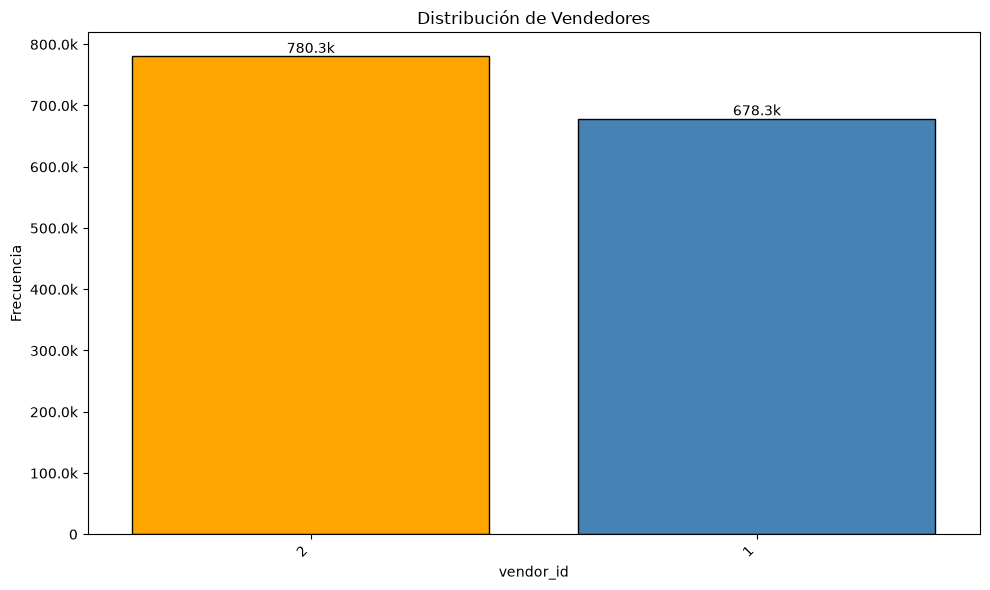

In [90]:
print(df['vendor_id'].value_counts())
diagrama_barras(df,'vendor_id','Distribución de Vendedores')

### **1.3.2 store_and_fwd_flag**

store_and_fwd_flag
N    1450599
Y       8045
Name: count, dtype: int64


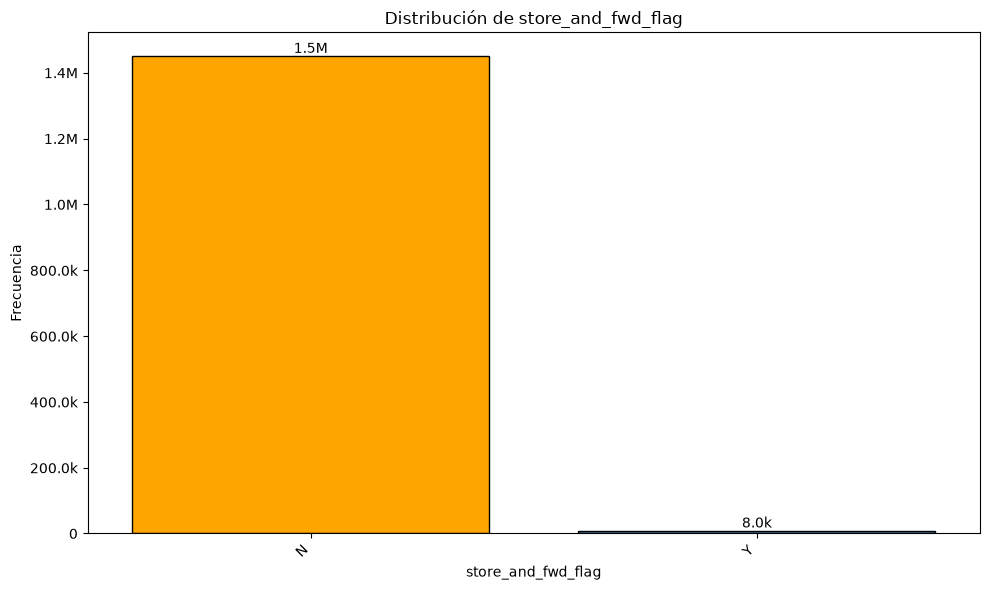

In [91]:
print(df['store_and_fwd_flag'].value_counts())
diagrama_barras(df,'store_and_fwd_flag')

### **1.3.3 passenger_count**

passenger_count
1    1033540
2     210318
5      78088
3      59896
6      48333
4      28404
0         60
7          3
9          1
8          1
Name: count, dtype: int64


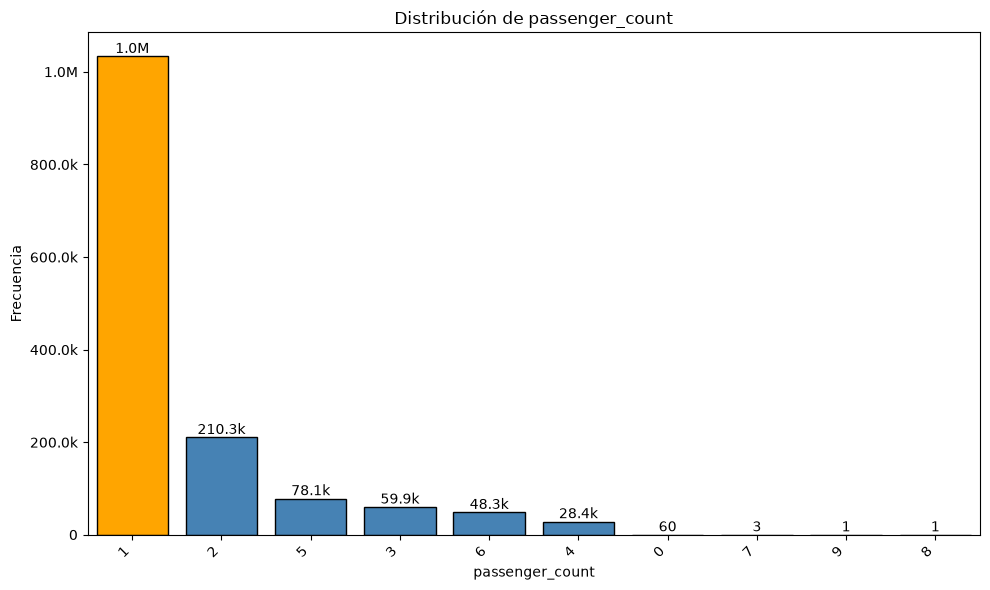

In [92]:
print(df['passenger_count'].value_counts())
diagrama_barras(df,'passenger_count')

**Observaciones**
- Existen 60 valores con viajes de 0 pasajeros, esto no tiene del todo sentido en el contexto, además de representar una porción isnsignificante en el dataset. Por tanto, se eliminarán estos registros.
- Las cantidad 7,8 y 9 de pasajeros son insignificantes teniendo en cuenta el tamaño del dataset. Por tanto, se prosige a eliminar los registros que poseen un número de pasajeros 0 (ilógico), además de 7,8 y 9 (poseen una proporción insignificante).

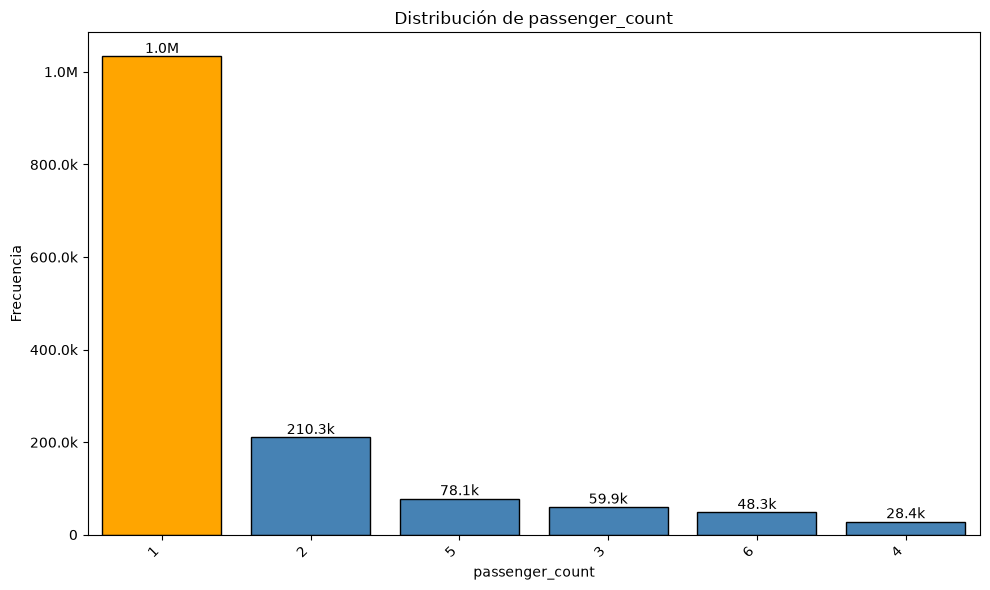

In [93]:
df = df[(df['passenger_count'] != 0) & (df['passenger_count'] < 7) ]
diagrama_barras(df,'passenger_count')

### **1.3.4 pickup_datetime**

- Como pickup_datetime esta en formato datetime, se analizará a partir de esta columna la distribución de viajes en los días de la semana.

In [94]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

# Se extrae el día y la hora del viaje
df['dia_semana_pickup'] = df['pickup_datetime'].dt.day_name()
df['horas_pickup'] = df['pickup_datetime'].dt.hour

# Número de Fechas únicas
df['pickup_datetime'].dt.date.nunique()

182

dia_semana_pickup
Friday       223521
Saturday     220855
Thursday     218566
Wednesday    210132
Tuesday      202745
Sunday       195352
Monday       187408
Name: count, dtype: int64


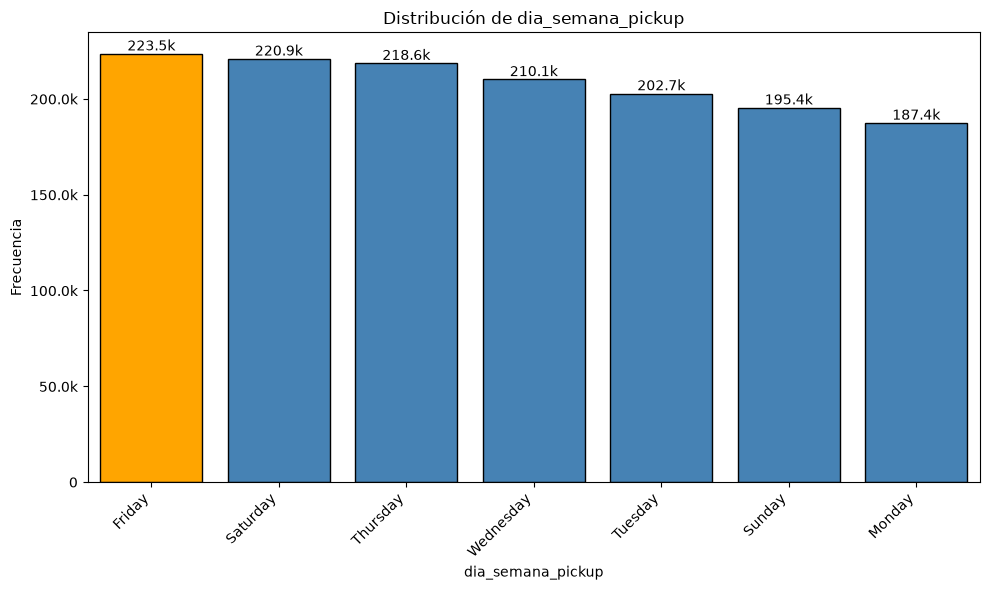

In [95]:
print(df['dia_semana_pickup'].value_counts())
diagrama_barras(df,'dia_semana_pickup')

horas_pickup
18    90599
19    90301
21    84181
20    84069
22    80489
17    76481
14    74289
12    71870
15    71810
13    71473
23    69780
11    68475
9     67662
8     67051
10    65436
16    64310
7     55600
0     53243
1     38562
6     33247
2     27970
3     20894
4     15790
5     14997
Name: count, dtype: int64


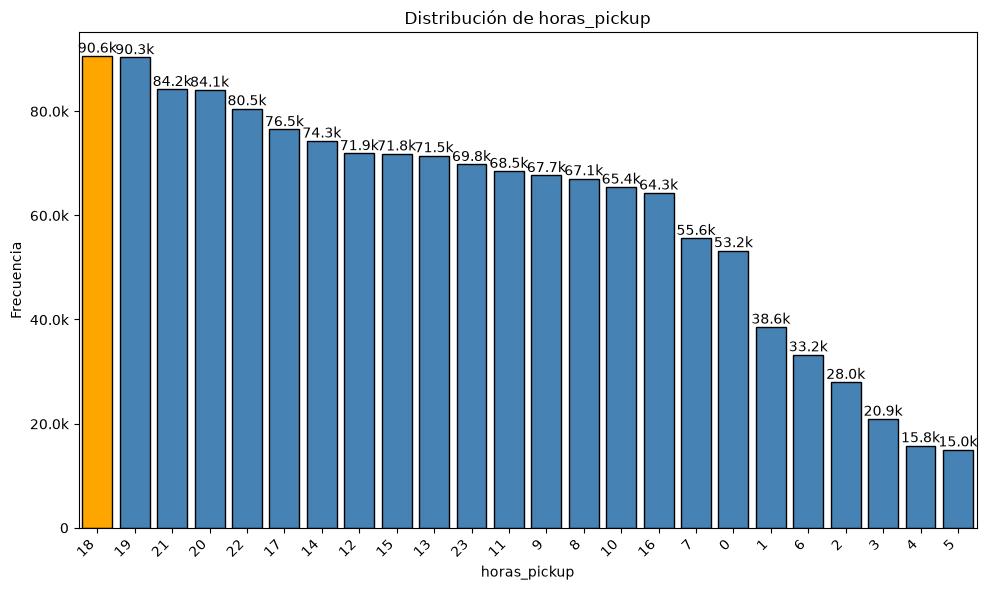

In [96]:
print(df['horas_pickup'].value_counts())
diagrama_barras(df,'horas_pickup')

### **1.3.5 dropoff_datetime**

In [97]:
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])

# Se extrae el día y la hora del viaje
df['dia_semana_dropoff'] = df['dropoff_datetime'].dt.day_name()
df['horas_dropoff'] = df['dropoff_datetime'].dt.hour

# Número de Fechas únicas
df['dropoff_datetime'].dt.date.nunique()

183

dia_semana_dropoff
Friday       223020
Saturday     220888
Thursday     217738
Wednesday    209786
Tuesday      202513
Sunday       197210
Monday       187424
Name: count, dtype: int64


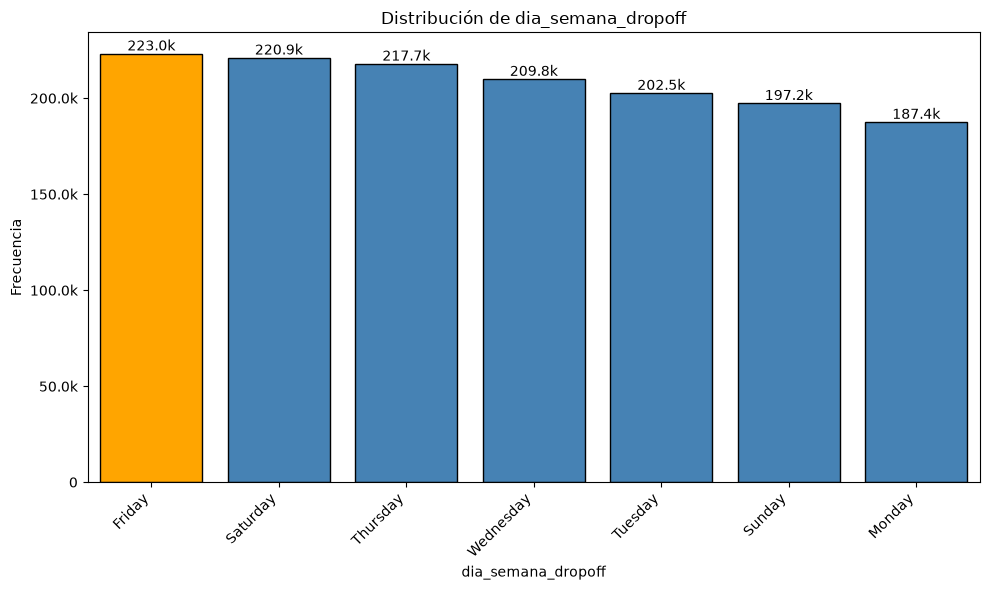

In [98]:
print(df['dia_semana_dropoff'].value_counts())
diagrama_barras(df,'dia_semana_dropoff')

horas_dropoff
19    93424
18    89587
20    85334
21    83616
22    81564
15    73108
23    72592
14    72387
17    72018
12    71600
13    71209
9     67525
11    66821
10    66052
16    65914
8     64104
0     57805
7     49939
1     41751
2     29843
6     29233
3     22085
4     17035
5     14033
Name: count, dtype: int64


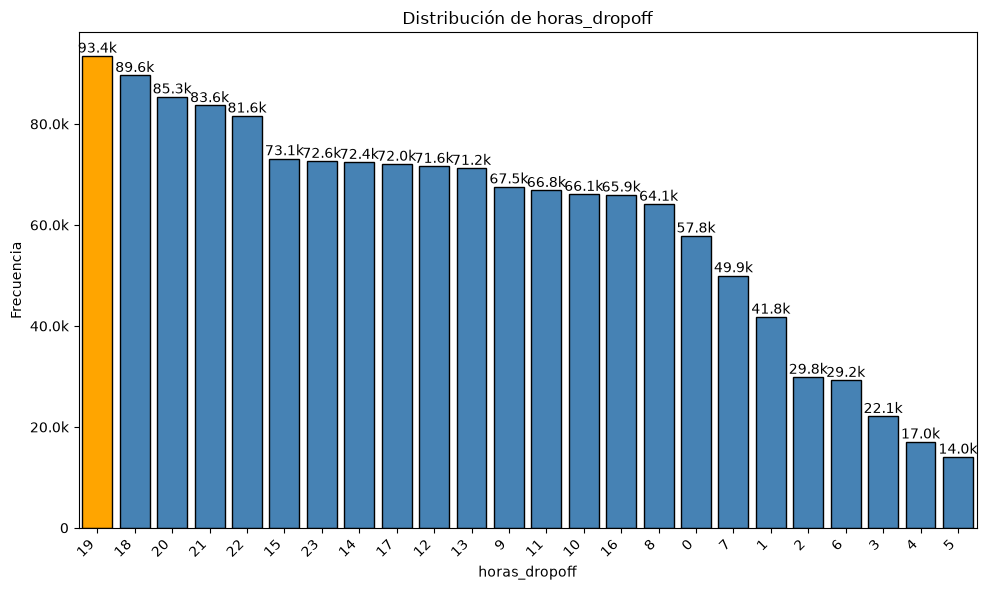

In [99]:
print(df['horas_dropoff'].value_counts())
diagrama_barras(df,'horas_dropoff')

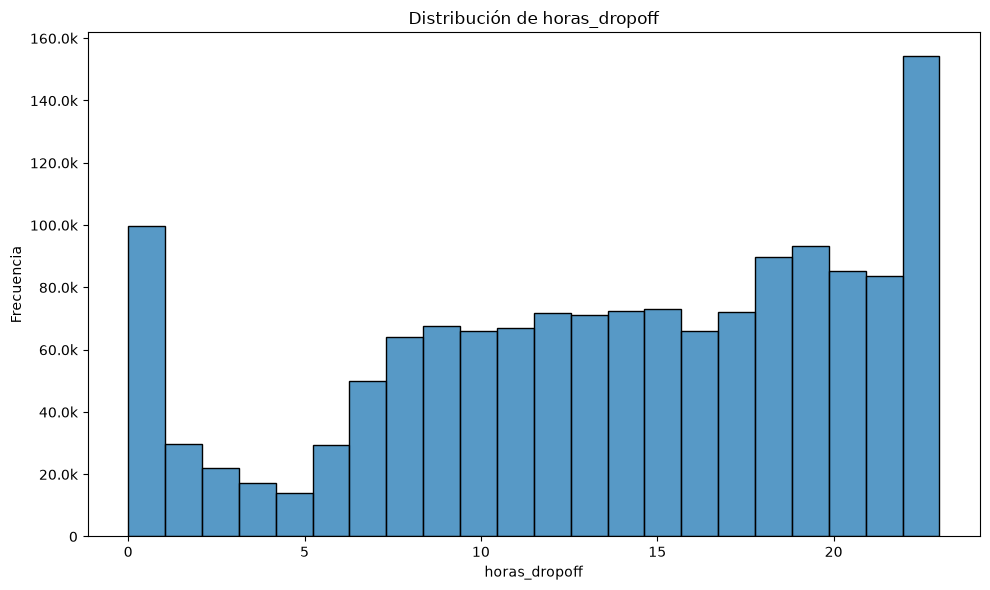

Observaciones: 1,458,579
Bins (Sturges): 22


In [100]:
histograma_sturges(df,'horas_dropoff')

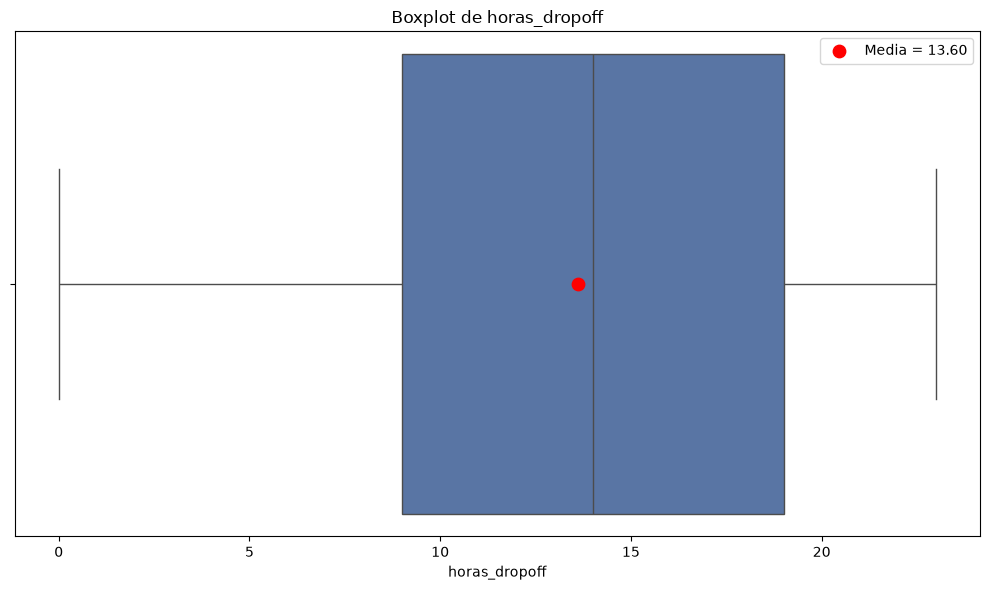

Observaciones: 1,458,579
Media: 13.60
Mínimo: 0.00
Q1 (P25): 9.00
Mediana (P50): 14.00
Q3 (P75): 19.00
Máximo: 23.00


In [101]:
boxplot(df,'horas_dropoff')

### **1.3.6 trip_duration**

trip_duration
1           32
2          175
3          314
4          312
5          283
          ... 
86392        1
1939736      1
2049578      1
2227612      1
3526282      1
Name: count, Length: 7416, dtype: int64


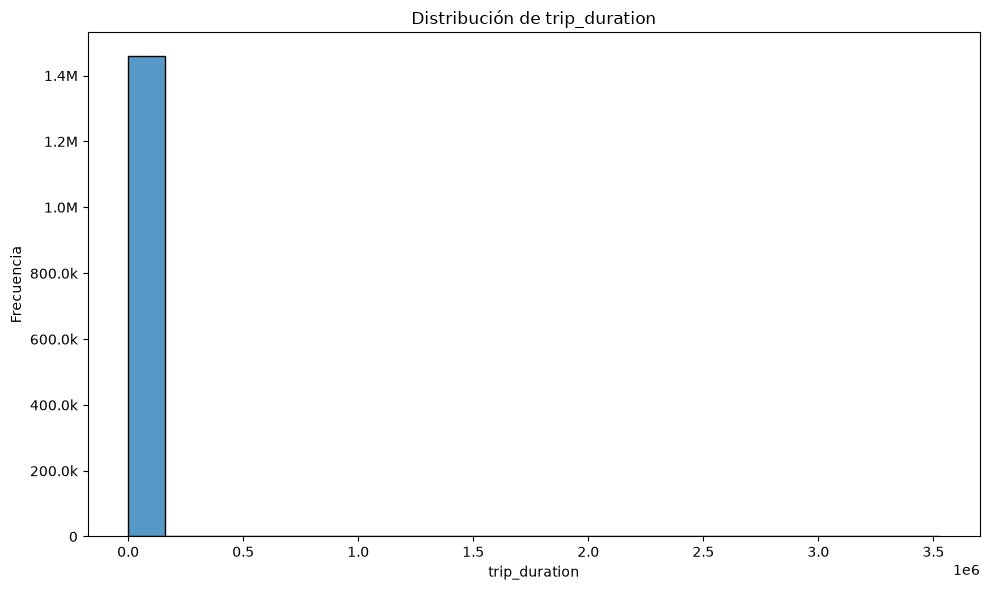

Observaciones: 1,458,579
Bins (Sturges): 22


In [102]:
print(df['trip_duration'].value_counts().sort_index())
histograma_sturges(df,'trip_duration')

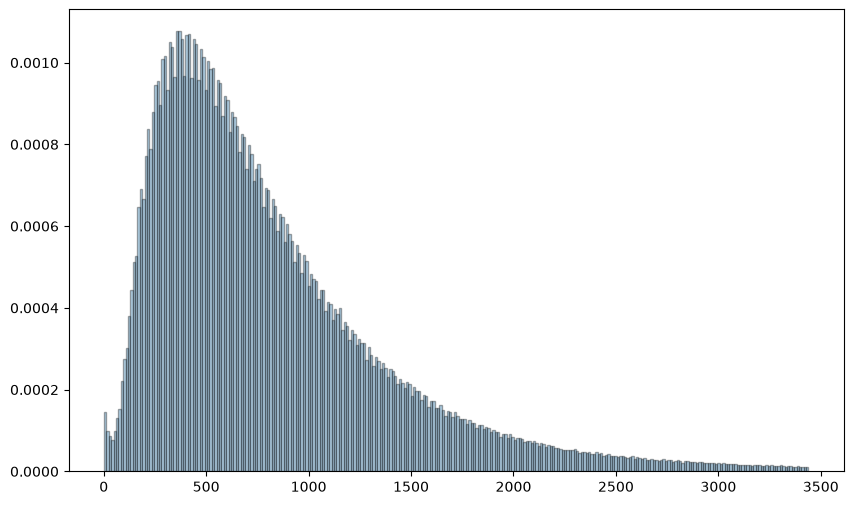

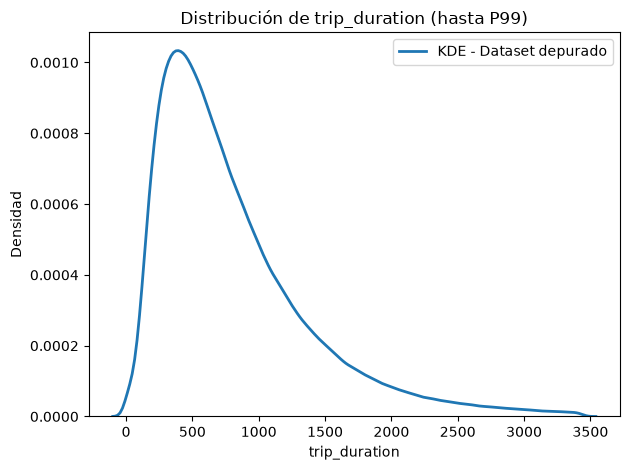

In [103]:
hist_kde(df,'trip_duration')

**Observaciones**
- La variable está medida en segundos, esto impide observar la visualización de una forma más comoda. Por consiguiente, posteriormente se pasara a minutos. No obstante, es relevante observar algunos percentiles.

In [104]:
percentiles = df['trip_duration'].quantile(
    [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
) / 60

percentiles.index = [
    'P1', 'P5', 'P10', 'P25', 'P50',
    'P75', 'P90', 'P95', 'P99'
]

print(percentiles)

P1      1.450000
P5      3.000000
P10     4.083333
P25     6.616667
P50    11.033333
P75    17.916667
P90    27.233333
P95    35.066667
P99    57.333333
Name: trip_duration, dtype: float64


In [105]:
print("Cantidad de Viajes con tiempo de duración menor a  30s: ",df[df['trip_duration'] <30].shape[0])
print(f"Proporción: {df[df['trip_duration'] < 30].shape[0]/df.shape[0]:.3f}")

Cantidad de Viajes con tiempo de duración menor a  30s:  4744
Proporción: 0.003


**Observaciones**
- Existen viajes que presentaron una duración menor a 30 segundos que equivalen al 0.3% de los viajes. 
- Para cuestiones de este análisis, se omitirán estos datos, debido a que el hecho de que un viaje tuviera una duración menor a 30 segundos se podría considerar una anomalía, además de que representar una porción casi insignificante de todo el dataset.

In [106]:
df = df[df['trip_duration'] >= 30]

In [107]:
df['trip_duration'] = df['trip_duration'] / 60

In [108]:
df[df['trip_duration'] > 100]

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,dia_semana_pickup,horas_pickup,dia_semana_dropoff,horas_dropoff
354,id3402983,2,2016-06-30 15:48:06,2016-06-30 17:31:13,1,-73.781898,40.644772,-73.985893,40.760159,N,103.116667,Thursday,15,Thursday,17
531,id3307903,2,2016-02-20 04:03:06,2016-02-21 03:33:00,3,-74.008102,40.741489,-74.009956,40.714611,N,1409.900000,Saturday,4,Sunday,3
1134,id1091477,2,2016-05-07 18:36:22,2016-05-08 18:32:11,1,-73.990242,40.750919,-73.976280,40.750889,N,1435.816667,Saturday,18,Sunday,18
1865,id3431345,2,2016-06-07 12:58:48,2016-06-08 12:58:00,6,-73.954956,40.777649,-73.981033,40.743713,N,1439.200000,Tuesday,12,Wednesday,12
3092,id0296060,2,2016-06-16 08:07:39,2016-06-16 10:11:39,2,-73.779083,40.647491,-74.006996,40.708523,N,124.000000,Thursday,8,Thursday,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455536,id2199367,1,2016-05-13 14:58:45,2016-05-13 16:40:49,1,-73.983116,40.771484,-73.789848,40.643478,N,102.066667,Friday,14,Friday,16
1456458,id2055880,2,2016-02-08 19:11:31,2016-02-09 19:08:44,3,-73.973282,40.760792,-73.988518,40.764210,N,1437.216667,Monday,19,Tuesday,19
1457207,id1910950,2,2016-06-08 16:29:12,2016-06-09 16:11:03,1,-73.958061,40.800869,-73.964119,40.805515,N,1421.850000,Wednesday,16,Thursday,16
1457752,id1215198,2,2016-02-02 11:31:10,2016-02-03 11:29:44,6,-73.972069,40.794220,-73.961014,40.806728,N,1438.566667,Tuesday,11,Wednesday,11


trip_duration
6.133333       1624
6.800000       1584
5.800000       1582
6.116667       1581
5.966667       1577
               ... 
85.533333         1
1436.666667       1
191.883333        1
1208.400000       1
102.066667        1
Name: count, Length: 7387, dtype: int64


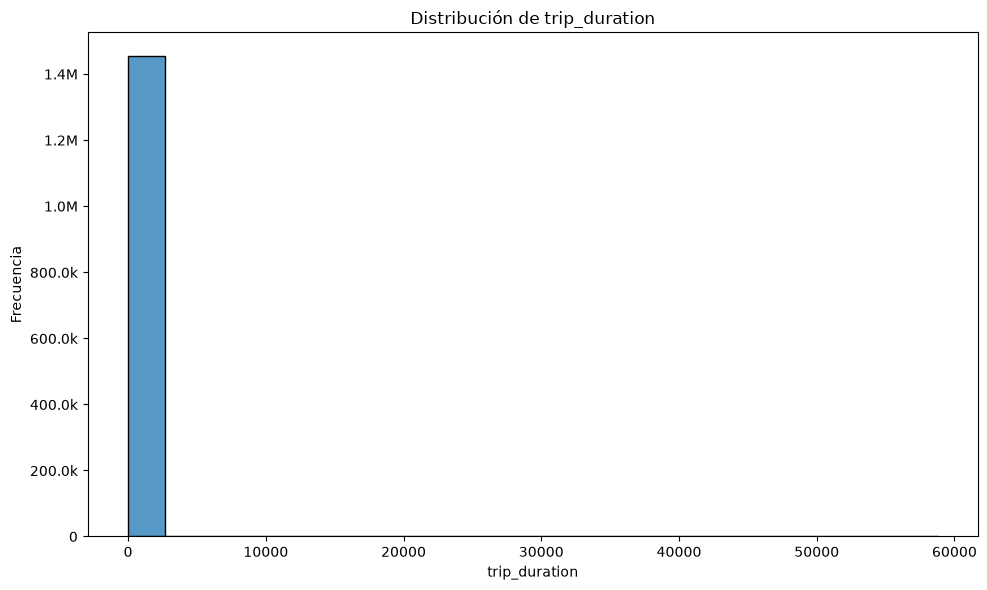

Observaciones: 1,453,835
Bins (Sturges): 22


In [109]:
print(df['trip_duration'].value_counts())
histograma_sturges(df,'trip_duration')

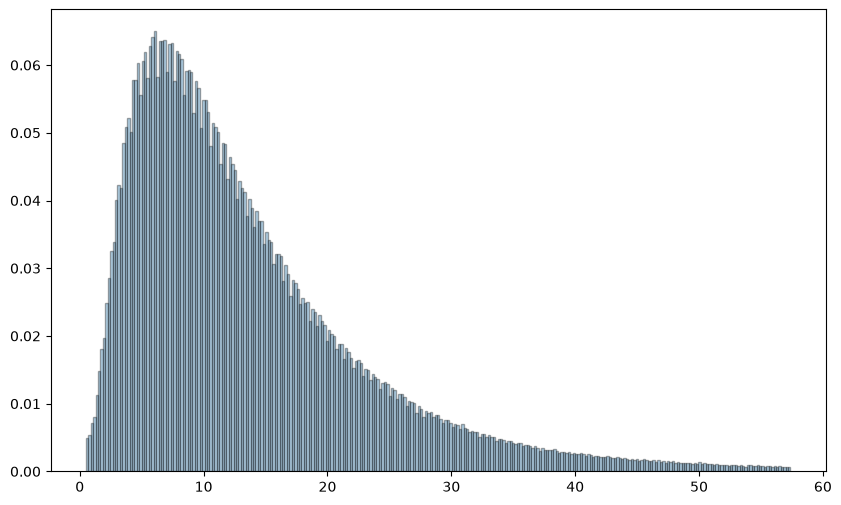

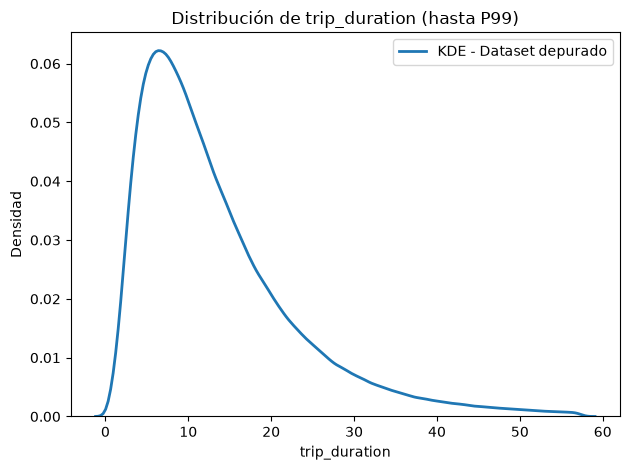

In [110]:
hist_kde(df,'trip_duration',99)

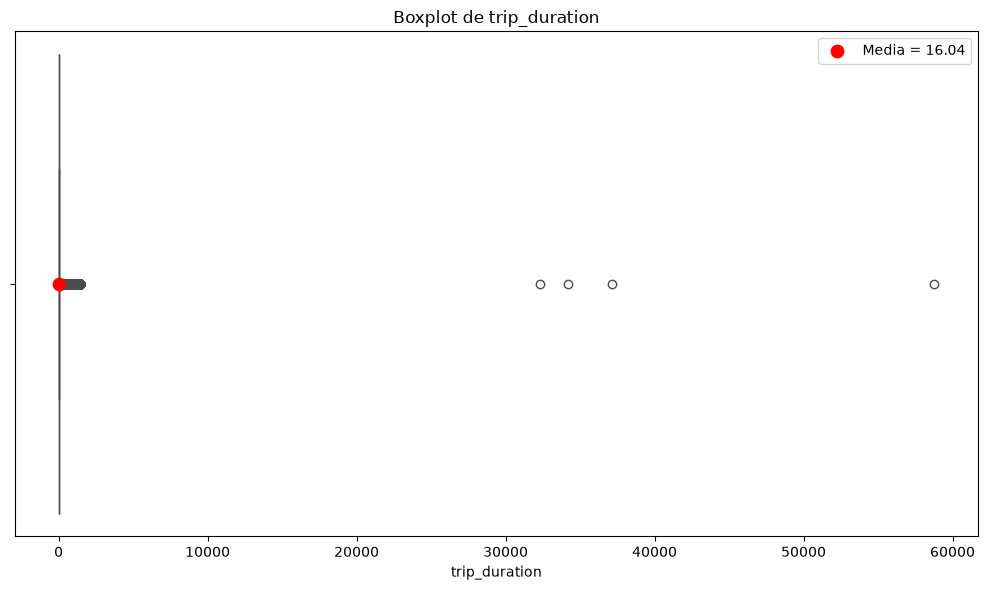

Observaciones: 1,453,835
Media: 16.04
Mínimo: 0.50
Q1 (P25): 6.65
Mediana (P50): 11.07
Q3 (P75): 17.95
Máximo: 58,771.37


In [111]:
boxplot(df,'trip_duration')

**Observaciones**
- Existen varios valores atípicos que generan un sesgo en la distribución

In [112]:
percentiles = df['trip_duration'].quantile(
    [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
) 

percentiles.index = [
    'P1', 'P5', 'P10', 'P25', 'P50',
    'P75', 'P90', 'P95', 'P99'
]

print(percentiles)

P1      1.683333
P5      3.083333
P10     4.133333
P25     6.650000
P50    11.066667
P75    17.950000
P90    27.266667
P95    35.116667
P99    57.383333
Name: trip_duration, dtype: float64


### **1.3.7 pickup_longitud/pickup_latitude**

In [113]:
def mapa_calor(df,cols, zoom_start=11):

    latitude, longitude = cols[0], cols[1]
    datos = df[
        [latitude, longitude]
    ].dropna()

    mapa = folium.Map(
        location=[
            datos[latitude].mean(),
            datos[longitude].mean()
        ],
        zoom_start=zoom_start,
        tiles=None,
        control_scale=True
    )

    # Mapa base CARTO Voyager
    folium.TileLayer(
        tiles=(
            "https://basemaps.cartocdn.com/"
            "rastertiles/voyager/{z}/{x}/{y}.png"
            f"?key={CARTO_KEY}"
        ),
        attr='&copy; OpenStreetMap contributors &copy; CARTO',
        name='CARTO Voyager',
        max_zoom=20
    ).add_to(mapa)

    # Coordenadas de los pickups
    puntos = datos[
        [latitude, longitude]
    ].values.tolist()

    # Heatmap
    HeatMap(
        puntos,
        radius=10,
        blur=15,
        min_opacity=0.3
    ).add_to(mapa)

    return mapa

In [114]:
archivo_mapa = "../output/maps/mapa_calor_pickup_population.html"

if os.path.exists(archivo_mapa):
    print("El mapa ya existe. Cargando...")
else:
    print("El mapa no existe. Creándolo...")
    mapa = mapa_calor(df, ['pickup_latitude', 'pickup_longitude'])
    mapa.save(archivo_mapa)

# Mostrar el HTML en Jupyter
display(IFrame(src=archivo_mapa, width="100%", height="600px"))

El mapa ya existe. Cargando...


#### **Identificación Municipios de los Viajes en Pickup**


In [115]:
print("Geojson Municipios:",boroughs.columns.tolist())
print("Geojson distritos: ", districts.columns.tolist())

Geojson Municipios: [':id', ':version', ':created_at', ':updated_at', 'borocode', 'boroname', 'shape_area', 'shape_leng', 'geometry']
Geojson distritos:  [':id', ':version', ':created_at', ':updated_at', 'boro_cd', 'shape_leng', 'shape_area', 'geometry']


In [116]:
print("Geometría Municipios \n", boroughs.geometry)
print("Geometría Distritos \n",districts.geometry)

Geometría Municipios 
 0    MULTIPOLYGON (((-74.05051 40.56642, -74.05047 ...
1    MULTIPOLYGON (((-73.86327 40.58388, -73.86381 ...
2    MULTIPOLYGON (((-73.82645 40.59053, -73.82642 ...
3    MULTIPOLYGON (((-74.01093 40.68449, -74.01193 ...
4    MULTIPOLYGON (((-73.89681 40.79581, -73.89694 ...
Name: geometry, dtype: geometry
Geometría Distritos 
 0     MULTIPOLYGON (((-73.85722 40.65028, -73.85902 ...
1     MULTIPOLYGON (((-73.74694 40.63755, -73.74694 ...
2     MULTIPOLYGON (((-73.8679 40.90294, -73.86796 4...
3     MULTIPOLYGON (((-73.98372 40.59582, -73.98305 ...
4     MULTIPOLYGON (((-73.97301 40.76428, -73.97141 ...
                            ...                        
66    MULTIPOLYGON (((-73.87054 40.86967, -73.87053 ...
67    MULTIPOLYGON (((-73.90129 40.82048, -73.9016 4...
68    MULTIPOLYGON (((-73.89681 40.79581, -73.89694 ...
69    MULTIPOLYGON (((-73.78833 40.83467, -73.78931 ...
70    MULTIPOLYGON (((-73.77322 40.86079, -73.77326 ...
Name: geometry, Length: 71, dtyp

In [117]:
viajes_pickup = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(
        df['pickup_longitude'],
        df['pickup_latitude']
    ),
    crs='EPSG:4326'
)

In [118]:
# Municipios
viajes_boroughs_pickup = gpd.sjoin(
    viajes_pickup,
    boroughs[['boroname', 'geometry']],
    how='left',
    predicate='within'
)

# Distritos
viajes_districts_pickup = gpd.sjoin(
    viajes_pickup,
    districts[['boro_cd', 'geometry']],
    how='left',
    predicate='within'
)

In [119]:
df['borough_pickup'] = viajes_boroughs_pickup['boroname']
df['district_pickup'] = viajes_districts_pickup['boro_cd']

In [120]:
print("Municipios")
print("Valores Únicos: ", df['borough_pickup'].unique())
print("Cantidad Valores Nulos: ",df['borough_pickup'].isnull().sum() )
print(f"Porcentaje de Valores Nulos:{(df['borough_pickup'].isnull().sum()/df.shape[0])*100:.3f}")
print("Distritos")
print("Valores Únicos: ", df['district_pickup'].unique())
print("Cantidad Valores Nulos: ",df['district_pickup'].isnull().sum() )
print(f"Porcentaje de Valores Nulos:{(df['district_pickup'].isnull().sum()/df.shape[0])*100:.3f}")

Municipios
Valores Únicos:  <StringArray>
['Manhattan', 'Brooklyn', 'Queens', 'Bronx', nan, 'Staten Island']
Length: 6, dtype: str
Cantidad Valores Nulos:  901
Porcentaje de Valores Nulos:0.062
Distritos
Valores Únicos:  <StringArray>
['104', '106', '105', '101', '107', '102', '108', '301', '103', '164', '111',
 '483', '480', '109', '402', '306', '404', '302', '110', '304', '401', '410',
 '308', '112', '307', '403', '318', '309', '303', '311', '355', '305', '406',
 '412', '407', '201', '317', '314', '208',   nan, '409', '312', '408', '413',
 '405', '226', '316', '207', '481', '205', '501', '204', '209', '310', '212',
 '315', '211', '502', '206', '210', '202', '356', '313', '203', '414', '411',
 '503', '227', '482', '595']
Length: 70, dtype: str
Cantidad Valores Nulos:  901
Porcentaje de Valores Nulos:0.062


**Observaciones**
- Existen lugares de inicio de viajes que no se encuentran en NYC, representando una diminuta fracción del total de viajes. No obstante, siguen siendo importantes para el análisis, De modo que se les asigna una categoría "Externo".

In [121]:
df['borough_pickup'] = df['borough_pickup'].fillna("Externo")
df['district_pickup'] = df['district_pickup'].fillna("Externo")

In [122]:
df['borough_pickup'].value_counts()

borough_pickup
Manhattan        1340992
Queens             84580
Brooklyn           26122
Bronx               1186
Externo              901
Staten Island         54
Name: count, dtype: int64

In [123]:
df['district_pickup'].value_counts()

district_pickup
105    356737
108    210573
104    154798
106    149815
102    138128
        ...  
226         3
227         3
356         1
503         1
595         1
Name: count, Length: 70, dtype: int64

In [124]:
df['district_pickup'].unique()

<StringArray>
[    '104',     '106',     '105',     '101',     '107',     '102',     '108',
     '301',     '103',     '164',     '111',     '483',     '480',     '109',
     '402',     '306',     '404',     '302',     '110',     '304',     '401',
     '410',     '308',     '112',     '307',     '403',     '318',     '309',
     '303',     '311',     '355',     '305',     '406',     '412',     '407',
     '201',     '317',     '314',     '208', 'Externo',     '409',     '312',
     '408',     '413',     '405',     '226',     '316',     '207',     '481',
     '205',     '501',     '204',     '209',     '310',     '212',     '315',
     '211',     '502',     '206',     '210',     '202',     '356',     '313',
     '203',     '414',     '411',     '503',     '227',     '482',     '595']
Length: 70, dtype: str

### **1.3.8 dropoff_longitude/dropoff_latitude**

In [125]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,dia_semana_pickup,horas_pickup,dia_semana_dropoff,horas_dropoff,borough_pickup,district_pickup
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,7.583333,Monday,17,Monday,17,Manhattan,104
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,11.050000,Sunday,0,Sunday,0,Manhattan,106
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,35.400000,Tuesday,11,Tuesday,12,Manhattan,105
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,7.150000,Wednesday,19,Wednesday,19,Manhattan,101
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,7.250000,Saturday,13,Saturday,13,Manhattan,107


In [126]:
archivo_mapa = "../output/maps/mapa_calor_dropoff_population.html"

if os.path.exists(archivo_mapa):
    print("El mapa ya existe. Cargando...")
else:
    print("El mapa no existe. Creándolo...")
    mapa = mapa_calor(df,['dropoff_latitude','dropoff_longitude'])
    mapa.save(archivo_mapa)

# Mostrar el HTML en Jupyter
display(IFrame(src=archivo_mapa, width="100%", height="600px"))

El mapa ya existe. Cargando...


In [127]:
viajes_dropoff = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(
        df['dropoff_longitude'],
        df['dropoff_latitude']
    ),
    crs='EPSG:4326'
)

In [128]:
# Municipios
viajes_boroughs_dropoff = gpd.sjoin(
    viajes_dropoff,
    boroughs[['boroname', 'geometry']],
    how='left',
    predicate='within'
)

# Distritos
viajes_districts_dropoff = gpd.sjoin(
    viajes_dropoff,
    districts[['boro_cd', 'geometry']],
    how='left',
    predicate='within'
)

In [129]:
df['borough_dropoff'] = viajes_boroughs_dropoff['boroname']
df['district_dropoff'] = viajes_districts_dropoff['boro_cd']

In [130]:
print("Municipios")
print("Valores Únicos: ", df['borough_dropoff'].unique())
print("Cantidad Valores Nulos: ",df['borough_dropoff'].isnull().sum() )
print(f"Porcentaje de Valores Nulos:{(df['borough_dropoff'].isnull().sum()/df.shape[0])*100:.3f}")
print("Distritos")
print("Valores Únicos: ", df['district_dropoff'].unique())
print("Cantidad Valores Nulos: ",df['district_dropoff'].isnull().sum() )
print(f"Porcentaje de Valores Nulos:{(df['district_dropoff'].isnull().sum()/df.shape[0])*100:.3f}")

Municipios
Valores Únicos:  <StringArray>
['Manhattan', 'Queens', 'Brooklyn', 'Bronx', nan, 'Staten Island']
Length: 6, dtype: str
Cantidad Valores Nulos:  6010
Porcentaje de Valores Nulos:0.413
Distritos
Valores Únicos:  <StringArray>
['108', '102', '101', '107', '105', '401', '106', '103', '483', '110', '303',
 '302', '480', '306', '210', '104', '412', '112', '406', '164',   nan, '403',
 '314', '405', '408', '308', '111', '301', '304', '316', '402', '307', '209',
 '410', '109', '409', '404', '204', '313', '205', '202', '201', '355', '208',
 '211', '309', '318', '311', '305', '317', '413', '310', '407', '411', '312',
 '206', '482', '501', '203', '315', '212', '207', '228', '502', '481', '503',
 '414', '226', '227', '595', '356', '484']
Length: 72, dtype: str
Cantidad Valores Nulos:  6010
Porcentaje de Valores Nulos:0.413


**Observaciones**
- Existen lugares externos a NYC como destino del viaje, que representan una pequeña fracción de todos los viajes registrados. No obstante, como pueden llegar a ser relevantes para el análisis, se les asignará la etiqueta "Externo".

In [131]:
df['borough_dropoff'] = df['borough_dropoff'].fillna("Externo")
df['district_dropoff'] = df['district_dropoff'].fillna("Externo")

In [132]:
df['borough_dropoff'].value_counts()

borough_dropoff
Manhattan        1286145
Brooklyn           77242
Queens             74748
Bronx               9317
Externo             6010
Staten Island        373
Name: count, dtype: int64

In [133]:
df['district_dropoff'].value_counts()

district_dropoff
105    320106
108    204997
106    143967
104    143664
107    123735
        ...  
482        25
228        16
356        10
595         3
484         3
Name: count, Length: 72, dtype: int64

In [134]:
df['district_dropoff'].unique()

<StringArray>
[    '108',     '102',     '101',     '107',     '105',     '401',     '106',
     '103',     '483',     '110',     '303',     '302',     '480',     '306',
     '210',     '104',     '412',     '112',     '406',     '164', 'Externo',
     '403',     '314',     '405',     '408',     '308',     '111',     '301',
     '304',     '316',     '402',     '307',     '209',     '410',     '109',
     '409',     '404',     '204',     '313',     '205',     '202',     '201',
     '355',     '208',     '211',     '309',     '318',     '311',     '305',
     '317',     '413',     '310',     '407',     '411',     '312',     '206',
     '482',     '501',     '203',     '315',     '212',     '207',     '228',
     '502',     '481',     '503',     '414',     '226',     '227',     '595',
     '356',     '484']
Length: 72, dtype: str

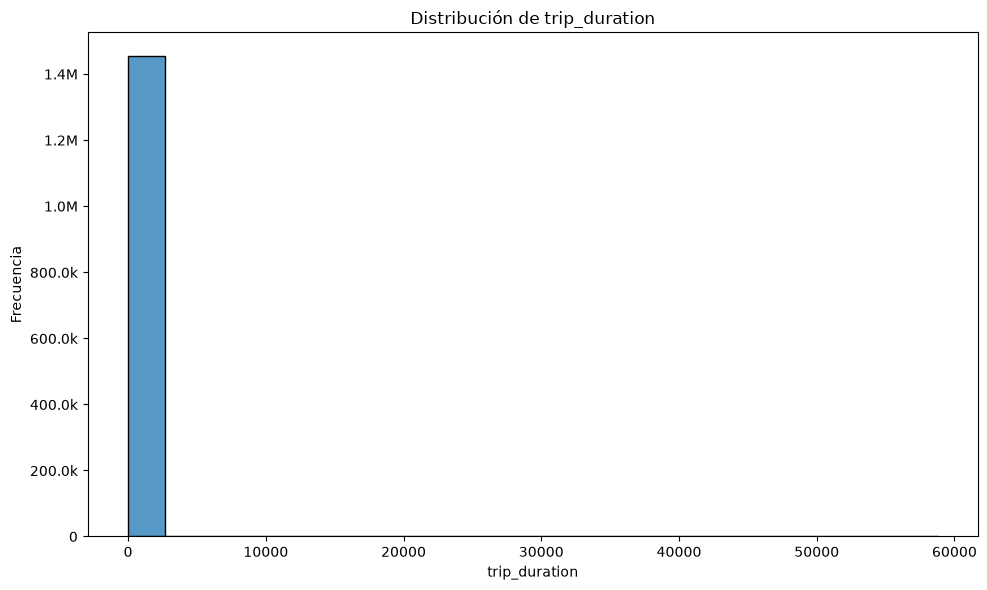

Observaciones: 1,453,835
Bins (Sturges): 22


In [135]:
histograma_sturges(df,'trip_duration')

## **1.4 Creación Nuevas Variables**

#### **Distancia geodésica** 

Para el cálculo de la distnacia geodésica, se implementaron las siguientes fórmulas.


Conversión de grados a radianes:

$$
\phi = \text{latitud}\cdot\frac{\pi}{180}
$$

$$
\lambda = \text{longitud}\cdot\frac{\pi}{180}
$$

Diferencias de latitud y longitud:

$$
\Delta\phi = \phi_2-\phi_1
$$

$$
\Delta\lambda = \lambda_2-\lambda_1
$$

Término de Haversine:

$$
a =
\sin^2\left(\frac{\Delta\phi}{2}\right)
+
\cos(\phi_1)\cos(\phi_2)
\sin^2\left(\frac{\Delta\lambda}{2}\right)
$$

Ángulo central:

$$
c =
2\arctan2\left(\sqrt{a},\sqrt{1-a}\right)
$$

Distancia geodésica:

$$
\boxed{d=R\,c}
$$

donde:

$$
R=6371\text{ km}
$$

Por lo tanto:

$$
\boxed{
d =
2R\arctan2
\left(
\sqrt{a},
\sqrt{1-a}
\right)
}

In [136]:
R = 6371  # Radio de la Tierra en km

lat1 = np.radians(df['pickup_latitude'])
lon1 = np.radians(df['pickup_longitude'])
lat2 = np.radians(df['dropoff_latitude'])
lon2 = np.radians(df['dropoff_longitude'])

dlat = lat2 - lat1
dlon = lon2 - lon1

a = (
    np.sin(dlat / 2)**2
    + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
)

c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

df['distancia_haversine_km'] = R * c

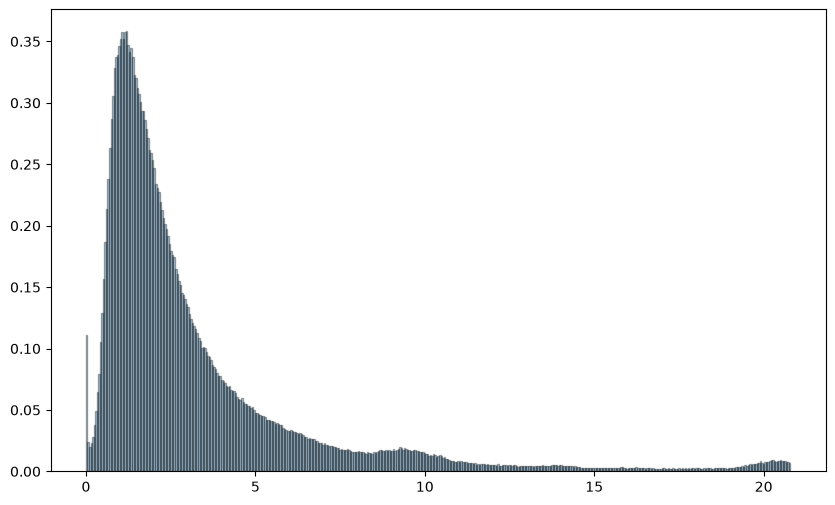

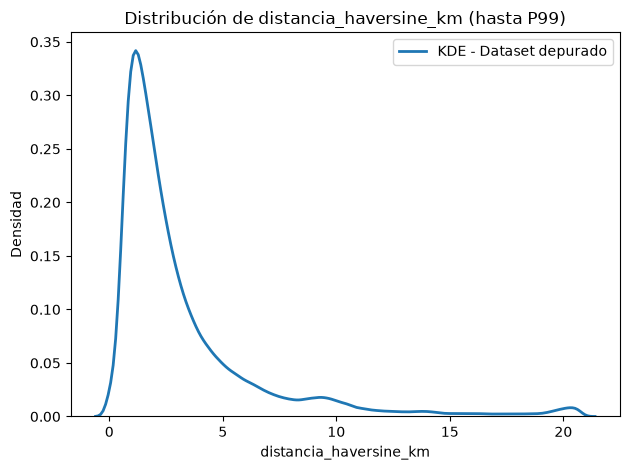

In [137]:
hist_kde(df,'distancia_haversine_km')

### **Velocidad Promedio del Viaje**

Para calcular la velocidad promedio del viaje, se utilizarán las unidades (km/h). Como las unidades de trip_duration ya están en minutos, solo se dividira en 60 para hacer la conversión. Asimismo, las unidades de distancia están ya definidad en kilómetros según la distancia Harvesine calculada.

In [138]:
df['velocidad_promedio_kmh'] = (
    df['distancia_haversine_km'] /
    (df['trip_duration'] / 60)
)

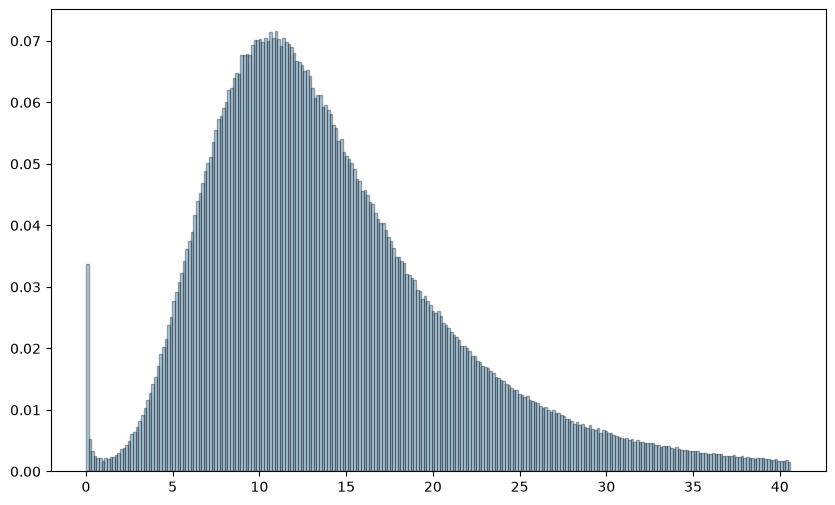

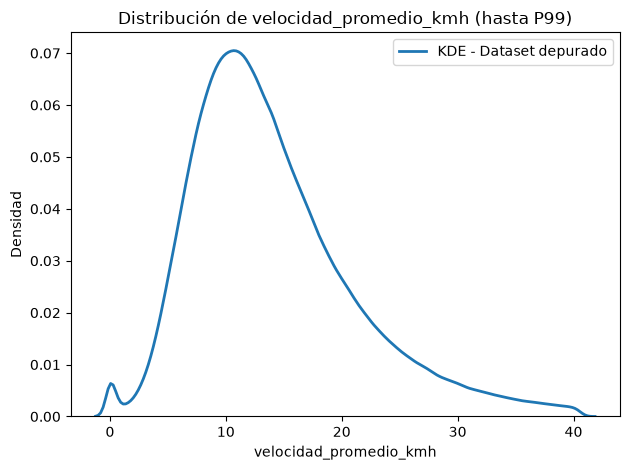

In [139]:
hist_kde(df,'velocidad_promedio_kmh')

In [140]:
df[df['velocidad_promedio_kmh'] == 0].shape

(4559, 21)

**Observaciones**
- Existen 4559 registros que no presentaron ningún tipo de desplazamiento.

## **1.5 Duplicados**

In [141]:
df[df.drop(columns=['id']).duplicated(keep=False)].shape

(14, 21)

**Observaciones**
- Existen 14 registros con valores duplicados quitando el id. Por tanto, se conservará la primera aparición del registro, debido a que la duplicación puede estar relacionada a un error del sistema (porque cada registro es un viaje independiente).

In [142]:
cols = df.columns.drop('id')

df = df.drop_duplicates(subset=cols, keep='first').copy()

# **2. Método de Muestreo**


## **2.1 Selección método de muestreo**

En lo referente a la selección del método de muestreo, se optó por el uso de un MAS (Muestreo Aleatorio Simple), debido a que el fin del estudio no está limitado a una característica en específica del Dataset, además de que se tiene acceso a los datos de toda la población. De la misma manera, el uso de este muestro probabilístico indica que cada observación tendrá la misma probabilidad conocida de ser seleccionada. 

De esta manera, se escogió un tamaño de 40.000 observaciones, debido a que se necesita un tamaño de muestra lo suficientemente grande para captar adecuadamente la variabilidad presente en la población y ejecutar modelos de aprendizaje no supervisado. También, este tamaño mantiene el equilibrio entre la representatividad de la población y el costo computacional requerido para los modelos.

In [143]:
muestra = df.sample(n=40000, random_state=42)

## **2.2 Comprobación de Representatividad de la Muestra**

In [144]:
def comprobar_categorica(df, muestra, columna):
    # Frecuencias de la población
    poblacion = df[columna].value_counts().sort_index()

    # Frecuencias de la muestra
    muestra_counts = (
        muestra[columna]
        .value_counts()
        .reindex(poblacion.index, fill_value=0)
    )

    # Frecuencias esperadas en la muestra
    esperadas = len(muestra) * poblacion / len(df)

    # Prueba Chi-cuadrado
    resultado = chisquare(
        f_obs=muestra_counts,
        f_exp=esperadas
    )

    # Tabla comparativa
    comparacion = pd.DataFrame({
        'Frecuencia población': poblacion,
        'Proporción población': poblacion / len(df),
        'Frecuencia muestra': muestra_counts,
        'Proporción muestra': muestra_counts / len(muestra)
    })

    comparacion['Diferencia'] = (
        comparacion['Proporción muestra']
        - comparacion['Proporción población']
    )

    print(f"Variable: {columna}")
    print(f"Chi-cuadrado: {resultado.statistic:.4f}")
    print(f"p-value: {resultado.pvalue:.4f}")

    if resultado.pvalue > 0.05:
        print("No se detectan diferencias estadísticamente significativas.")
    else:
        print("Se detectan diferencias estadísticamente significativas.")

    return comparacion

def comparar_hist_kde(df, muestra, columna, percentil=99):

    poblacion = df[columna].dropna()
    muestra_col = muestra[columna].dropna()

    # Límite visual para evitar que los extremos oculten la distribución
    limite = np.percentile(
        pd.concat([poblacion, muestra_col]),
        percentil
    )

    poblacion_plot = poblacion[poblacion <= limite]
    muestra_plot = muestra_col[muestra_col <= limite]

    # Mismos bins para ambas distribuciones
    datos = pd.concat([poblacion_plot, muestra_plot])
    bins = np.histogram_bin_edges(datos, bins='auto')

    # Gráfico
    plt.figure(figsize=(10, 6))

    # Histogramas
    plt.hist(
        poblacion_plot,
        bins=bins,
        density=True,
        alpha=0.35,
        edgecolor='black',
        label='Dataset depurado'
    )

    plt.hist(
        muestra_plot,
        bins=bins,
        density=True,
        alpha=0.35,
        edgecolor='black',
        label='Muestra'
    )
    plt.xlabel(columna)
    plt.ylabel('Densidad')
    plt.title("Histograma Depurado vs Muestra")
    plt.show()

    # KDE
    sns.kdeplot(
        poblacion_plot,
        linewidth=2,
        label='KDE - Dataset depurado'
    )

    sns.kdeplot(
        muestra_plot,
        linewidth=2,
        label='KDE - Muestra'
    )

    
    plt.title(
        f'Distribución de {columna}: población vs. muestra '
        f'(hasta P{percentil})'
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

### **2.2.1 vendor_id**

In [145]:
comprobar_categorica(df,muestra,'vendor_id')

Variable: vendor_id
Chi-cuadrado: 0.1447
p-value: 0.7036
No se detectan diferencias estadísticamente significativas.


,Frecuencia población,Proporción población,Frecuencia muestra,Proporción muestra,Diferencia
vendor_id,,,,,
1,675305,0.464501,18618,0.46545,0.000949
2,778523,0.535499,21382,0.53455,-0.000949


**Observaciones**
- Como el p-valor es mayor al 5%, no existe evidencia suficiente para descartar que existan diferencias significativas en la distribución de los vendedores.-En términos prácticos, la muestra si representa la distribución de vendedores de la población (dataset depurado).

### **2.2.2 store_and_fwd_flag**

In [146]:
comprobar_categorica(df,muestra,'store_and_fwd_flag')

Variable: store_and_fwd_flag
Chi-cuadrado: 7.6271
p-value: 0.0057
Se detectan diferencias estadísticamente significativas.


,Frecuencia población,Proporción población,Frecuencia muestra,Proporción muestra,Diferencia
store_and_fwd_flag,,,,,
N,1445878,0.994532,39822,0.99555,0.001018
Y,7950,0.005468,178,0.00445,-0.001018


**Observaciones**
- Como el p-valor es mayor al 5%, no existe evidencia suficiente para descartar que existan diferencias significativas en la distribución del indicador técnico store_and_fwd_flag de la muestra con el dataset depurado. En términos prácticos, la muestra si representa la distribución del indicador del dataset depurado.

### **2.2.3 passenger_count**

- Como el número de pasajeros presenta valores discretos, se puede tomar como una categoría para implementar una prueba chi2.

In [147]:
comprobar_categorica(df,muestra,'passenger_count')

Variable: passenger_count
Chi-cuadrado: 2.1790
p-value: 0.8239
No se detectan diferencias estadísticamente significativas.


,Frecuencia población,Proporción población,Frecuencia muestra,Proporción muestra,Diferencia
passenger_count,,,,,
1,1029611,0.708207,28243,0.706075,-0.002132
2,209848,0.144342,5772,0.144300,-0.000042
3,59786,0.041123,1661,0.041525,0.000402
4,28347,0.019498,800,0.020000,0.000502
5,77961,0.053625,2156,0.053900,0.000275
6,48275,0.033205,1368,0.034200,0.000995


**Observaciones**
- Como el p-valor es mayor al 5%, no existe evidencia suficiente para descartar que existan diferencias significativas en la distribución del número de pasajeros en los viajes de la muestra con la del dataset depurado. En términos prácticos, la muestra si representa la distribución del número de pasajeros en los viajes con respecto al dataset depurado.

### **2.2.4 pickup_datetime**

#### **Día de la Semana**

In [148]:
comprobar_categorica(df,muestra,'dia_semana_pickup')

Variable: dia_semana_pickup
Chi-cuadrado: 11.6445
p-value: 0.0704
No se detectan diferencias estadísticamente significativas.


,Frecuencia población,Proporción población,Frecuencia muestra,Proporción muestra,Diferencia
dia_semana_pickup,,,,,
Friday,222824,0.153267,5992,0.149800,-0.003467
Monday,186777,0.128473,5056,0.126400,-0.002073
Saturday,220193,0.151457,6016,0.150400,-0.001057
Sunday,194604,0.133856,5333,0.133325,-0.000531
Thursday,217811,0.149819,6050,0.151250,0.001431
Tuesday,202104,0.139015,5604,0.140100,0.001085
Wednesday,209515,0.144113,5949,0.148725,0.004612


**Observaciones**
- Como el p-valor es mayor al 5%, no existe evidencia suficiente para descartar que existan diferencias significativas en la distribución de los días de la semana (pickup) de los viajes en la muestra y el dataset depurado. En términos prácticos, la muestra si representa la distribución de los días de la semana (pickup) en los que suceden los viajes del dataset depurado.

#### **Hora**

In [149]:
comprobar_categorica(df,muestra,'horas_pickup')

Variable: horas_pickup
Chi-cuadrado: 17.9482
p-value: 0.7603
No se detectan diferencias estadísticamente significativas.


,Frecuencia población,Proporción población,Frecuencia muestra,Proporción muestra,Diferencia
horas_pickup,,,,,
0,53042,0.036484,1480,0.037000,0.000516
1,38428,0.026432,1055,0.026375,-0.000057
2,27863,0.019165,759,0.018975,-0.000190
3,20782,0.014295,556,0.013900,-0.000395
4,15678,0.010784,464,0.011600,0.000816
5,14871,0.010229,416,0.010400,0.000171
6,33077,0.022752,943,0.023575,0.000823
7,55419,0.038119,1498,0.037450,-0.000669
8,66884,0.046005,1838,0.045950,-0.000055


**Observaciones**
- Como el p-valor es mayor al 5%, no existe evidencia suficiente para descartar que existan diferencias significativas en la distribución del número de horas (pickup) en los viajes de la muestra y del dataset depurado. En términos prácticos, la muestra si representa la distribución del número de horas (pickup) del dataset depurado.

### **2.2.5 dropoff_datetime**

#### **Día Semana**

In [150]:
comprobar_categorica(df,muestra,'dia_semana_dropoff')

Variable: dia_semana_dropoff
Chi-cuadrado: 11.9434
p-value: 0.0632
No se detectan diferencias estadísticamente significativas.


,Frecuencia población,Proporción población,Frecuencia muestra,Proporción muestra,Diferencia
dia_semana_dropoff,,,,,
Friday,222323,0.152922,5970,0.14925,-0.003672
Monday,186791,0.128482,5054,0.12635,-0.002132
Saturday,220226,0.151480,6030,0.15075,-0.000730
Sunday,196464,0.135136,5374,0.13435,-0.000786
Thursday,216983,0.149249,6044,0.15110,0.001851
Tuesday,201872,0.138855,5596,0.13990,0.001045
Wednesday,209169,0.143875,5932,0.14830,0.004425


**Observaciones**
- Como el p-valor es mayor al 5%, no existe evidencia suficiente para descartar que existan diferencias significativas en la distribución de los días de la semana (dropoff) de los viajes en la muestra y el dataset depurado. En términos prácticos, la muestra si representa la distribución de los días de la semana (dropoff) en los que suceden los viajes del dataset depurado.

#### **Hora**

In [151]:
comprobar_categorica(df,muestra,'horas_dropoff')

Variable: horas_dropoff
Chi-cuadrado: 12.7121
p-value: 0.9580
No se detectan diferencias estadísticamente significativas.


,Frecuencia población,Proporción población,Frecuencia muestra,Proporción muestra,Diferencia
horas_dropoff,,,,,
0,57604,0.039622,1570,0.039250,-0.000372
1,41616,0.028625,1148,0.028700,0.000075
2,29737,0.020454,809,0.020225,-0.000229
3,21973,0.015114,601,0.015025,-0.000089
4,16922,0.011640,473,0.011825,0.000185
5,13908,0.009566,401,0.010025,0.000459
6,29063,0.019991,813,0.020325,0.000334
7,49757,0.034225,1387,0.034675,0.000450
8,63938,0.043979,1720,0.043000,-0.000979


**Observaciones**
- Como el p-valor es mayor al 5%, no existe evidencia suficiente para descartar que existan diferencias significativas en la distribución del número de horas (dropoff) en los viajes de la muestra y del dataset depurado. En términos prácticos, la muestra si representa la distribución del número de horas (dropoff) del dataset depurado.

### **2.2.6 trip_duration**

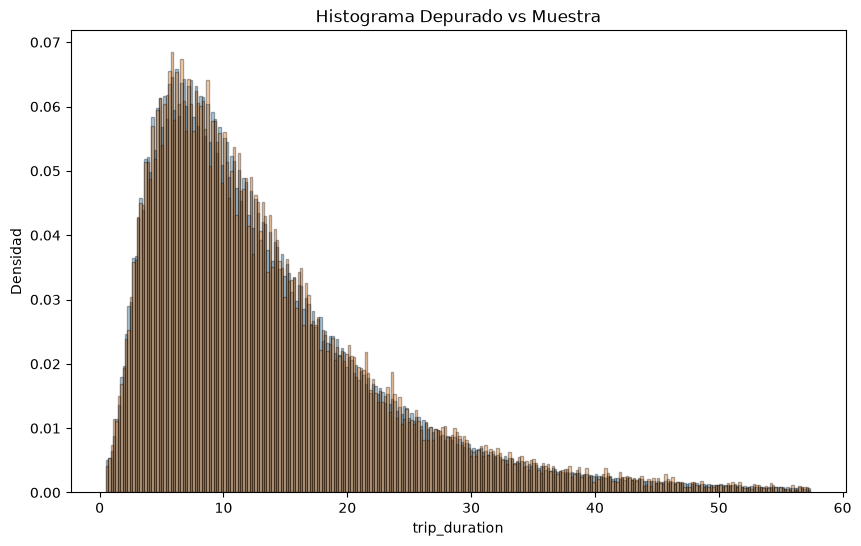

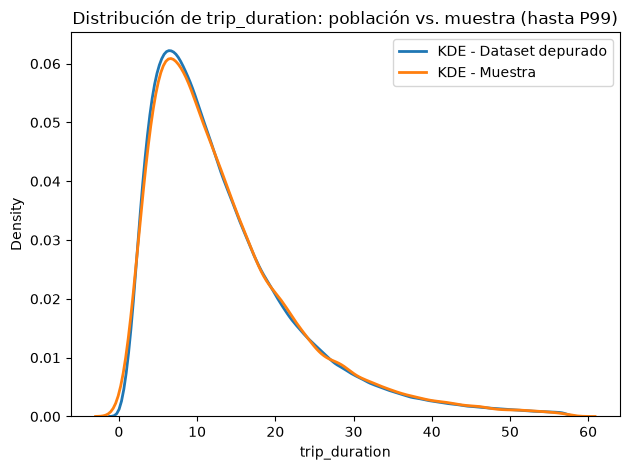

In [152]:
comparar_hist_kde(df,muestra,'trip_duration',99)

**Observaciones**
- El primer gráfico evidencia la similitud de la distribución del dataset depurado con la muestra, al tener una forma similar.
- El segundo gráfico (diagrama de densidad) muestra como la distribución de la muestra es casi idéntica a la de la distribución del dataset depurado.

### **2.2.7 pickup_longitude/pickup_latitude**

- Para identificar de una mejor forma la representatividad en variables geográficas, se opta por hacer la comprobación a partir de los municipios y distritos identificados.

In [153]:
comprobar_categorica(df,muestra,'borough_pickup')

Variable: borough_pickup
Chi-cuadrado: 4.2007
p-value: 0.5209
No se detectan diferencias estadísticamente significativas.


,Frecuencia población,Proporción población,Frecuencia muestra,Proporción muestra,Diferencia
borough_pickup,,,,,
Bronx,1186,0.000816,24,0.000600,-0.000216
Brooklyn,26121,0.017967,718,0.017950,-0.000017
Externo,901,0.000620,25,0.000625,0.000005
Manhattan,1340987,0.922384,36874,0.921850,-0.000534
Queens,84579,0.058177,2356,0.058900,0.000723
Staten Island,54,0.000037,3,0.000075,0.000038


**Observaciones**
- Como el p-valor es mayor al 5%, no existe evidencia suficiente para descartar que existan diferencias significativas entre las distribuciones del municipios de inicio del viaje (pick up) de la muestra y del dataset depurado. En términos prácticos, la muestra si representa la distribución de los municipios en los que se iniciaron los viajes (pickup) en comparación al dataset depurado.

In [154]:
comprobar_categorica(df,muestra,'district_pickup')

Variable: district_pickup
Chi-cuadrado: 51.1871
p-value: 0.9466
No se detectan diferencias estadísticamente significativas.


,Frecuencia población,Proporción población,Frecuencia muestra,Proporción muestra,Diferencia
district_pickup,,,,,
101,71086,4.889574e-02,1906,0.047650,-1.245743e-03
102,138127,9.500918e-02,3736,0.093400,-1.609176e-03
103,79994,5.502302e-02,2221,0.055525,5.019849e-04
104,154798,1.064761e-01,4312,0.107800,1.323856e-03
105,356737,2.453777e-01,9827,0.245675,2.972799e-04
...,...,...,...,...,...
501,46,3.164061e-05,2,0.000050,1.835939e-05
502,6,4.127036e-06,1,0.000025,2.087296e-05
503,1,6.878393e-07,0,0.000000,-6.878393e-07


**Observaciones**
- Como el p-valor es mayor al 5%, no existe evidencia suficiente para descartar que existan diferencias significativas entre las distribuciones de los distritos de inicio del viaje (pick up) de la muestra y del dataset depurado. En términos prácticos, la muestra si representa la distribución de los distritos en los que se iniciaron los viajes (pickup) en comparación al dataset depurado.

### **2.2.8 dropoff_longitude/dropoff_latitude**

In [155]:
comprobar_categorica(df,muestra,'borough_dropoff')

Variable: borough_dropoff
Chi-cuadrado: 4.0946
p-value: 0.5359
No se detectan diferencias estadísticamente significativas.


,Frecuencia población,Proporción población,Frecuencia muestra,Proporción muestra,Diferencia
borough_dropoff,,,,,
Bronx,9317,0.006409,283,0.007075,0.000666
Brooklyn,77241,0.053129,2157,0.053925,0.000796
Externo,6010,0.004134,156,0.003900,-0.000234
Manhattan,1286139,0.884657,35355,0.883875,-0.000782
Queens,74748,0.051415,2040,0.051000,-0.000415
Staten Island,373,0.000257,9,0.000225,-0.000032


**Observaciones**
- Como el p-valor es mayor al 5%, no existe evidencia suficiente para descartar que existan diferencias significativas entre las distribuciones del municipios de destino (drop off) de la muestra y del dataset depurado. En términos prácticos, la muestra si representa la distribución de los municipios en los que se iniciaron los viajes (dropoff) en comparación al dataset depurado.

In [156]:
comprobar_categorica(df,muestra,'district_dropoff')

Variable: district_dropoff
Chi-cuadrado: 65.9276
p-value: 0.6480
No se detectan diferencias estadísticamente significativas.


,Frecuencia población,Proporción población,Frecuencia muestra,Proporción muestra,Diferencia
district_dropoff,,,,,
101,71193,0.048969,1927,0.048175,-0.000794
102,117628,0.080909,3225,0.080625,-0.000284
103,72982,0.050200,2032,0.050800,0.000600
104,143663,0.098817,3891,0.097275,-0.001542
105,320106,0.220181,8913,0.222825,0.002644
...,...,...,...,...,...
501,188,0.000129,5,0.000125,-0.000004
502,129,0.000089,3,0.000075,-0.000014
503,53,0.000036,1,0.000025,-0.000011


**Observaciones**
- Como el p-valor es mayor al 5%, no existe evidencia suficiente para descartar que existan diferencias significativas entre las distribuciones de los distritos de destino del viaje (drop off) de la muestra y del dataset depurado. En términos prácticos, la muestra si representa la distribución de los distritos en los que se iniciaron los viajes (drop off) en comparación al dataset depurado.

In [157]:
muestra.to_csv("../data/processed.csv")